<a href="https://colab.research.google.com/github/hikaaru13/PCVK-GANJIL-TUGAS/blob/main/PERTANYAAN_PRAKTIKUM_PERTEMUAN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Alasannya: OpenCV secara default ngebaca gambar pake urutan warna BGR (Blue-Green-Red). cv2_imshow() di Colab emang didesain khusus buat nampilkan format BGR ini, makanya warnanya normal. Tapi kalau plt.imshow() dari Matplotlib itu mikirnya gambar yang masuk berformat RGB. Karena warnanya gak dikonversi dulu, kanal Merah sama Biru ketukar,makanya tampilan gambarnya jadi aneh atau blueish.

In [ ]:
import cv2
img = cv2.imread('/content/drive/MyDrive/PCVK/POTRAIT.jpeg')
print("Piksel [0,0] format BGR asli:", img[0,0])


Piksel [0,0] format BGR asli: [6 8 2]


2. Tampilan visual: Sama saja, gak ada bedanya. Dua duanya bakal kelihatan serba hitam karena semua nilai pikselnya dimulai dari 0.

Ukuran memori: Beda jauh. Tipe data int32 makan memori dua kali lipat dibanding int16. int16 cuma butuh 2 byte per elemen, sedangkan int32 butuh 4 byte per elemen.

In [ ]:
import numpy as np

shape = (600, 900, 3)
kanvas_16 = np.zeros(shape, dtype=np.int16)
kanvas_32 = np.zeros(shape, dtype=np.int32)

print(f"int16 -> dtype: {kanvas_16.dtype}, min: {kanvas_16.min()}, max: {kanvas_16.max()}, nbytes: {kanvas_16.nbytes}")
print(f"int32 -> dtype: {kanvas_32.dtype}, min: {kanvas_32.min()}, max: {kanvas_32.max()}, nbytes: {kanvas_32.nbytes}")



int16 -> dtype: int16, min: 0, max: 0, nbytes: 3240000
int32 -> dtype: int32, min: 0, max: 0, nbytes: 6480000


3. Fungsi from google.colab.patches import cv2_imshow & kenapa cv2.imshow() biasa error?
cv2.imshow() bawaan OpenCV itu sejatinya nyoba bikin jendela pop-up GUI di sistem operasi lokal komputer. Masalahnya, Google Colab itu jalannya di cloud server (sistemnya headless/tanpa layar monitor). Kalau dipaksa dipanggil, Colab bakal crash. Nah, fungsi cv2_imshow dari patches ini disediakan Google buat ngegantiin pop-up tadi biar gambarnya bisa langsung dirender di dalam sel notebook Colab.

4. skimage.io.imread() vs cv2.cvtColor()

Mana yang benar? Dua-duanya nampilin warna asli yang benar kalau di-plot pake Matplotlib. skimage.io.imread() dari awal udah otomatis ngebaca gambar ke format RGB. Sedangkan cv2.cvtColor(..., COLOR_BGR2RGB) itu ngubah paksa format BGR bawaan OpenCV jadi RGB. Jadi matriks akhir keduanya 100% identik.
buktinya:

In [ ]:
from skimage import io
img_skimage = io.imread('/content/drive/MyDrive/PCVK/POTRAIT.jpeg')
img_cv_rgb = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/POTRAIT.jpeg'), cv2.COLOR_BGR2RGB)

print("Piksel [0,0] skimage:", img_skimage[0,0])
print("Piksel [0,0] cvtColor:", img_cv_rgb[0,0])
print("Apakah matriks sama persis?", np.array_equal(img_skimage, img_cv_rgb))


Piksel [0,0] skimage: [2 8 6]
Piksel [0,0] cvtColor: [2 8 6]
Apakah matriks sama persis? True


5. Apakah img.shape berubah? Tidak, nilainya tetap sama.

Penjelasannya: Mengubah figsize di Matplotlib itu cuma ibarat Zoom In / Zoom Out tampilan layar aja tanpa ngutak-ngatik data asli gambarnya. Kalau mau benar-benar ngubah dimensi piksel dan nilai img.shape-nya, kita harus panggil fungsi pemotong/pengubah ukuran kayak cv2.resize().

Shape sebelum figsize: (1280, 960, 3)
Shape setelah plot figsize (20,20): (1280, 960, 3)


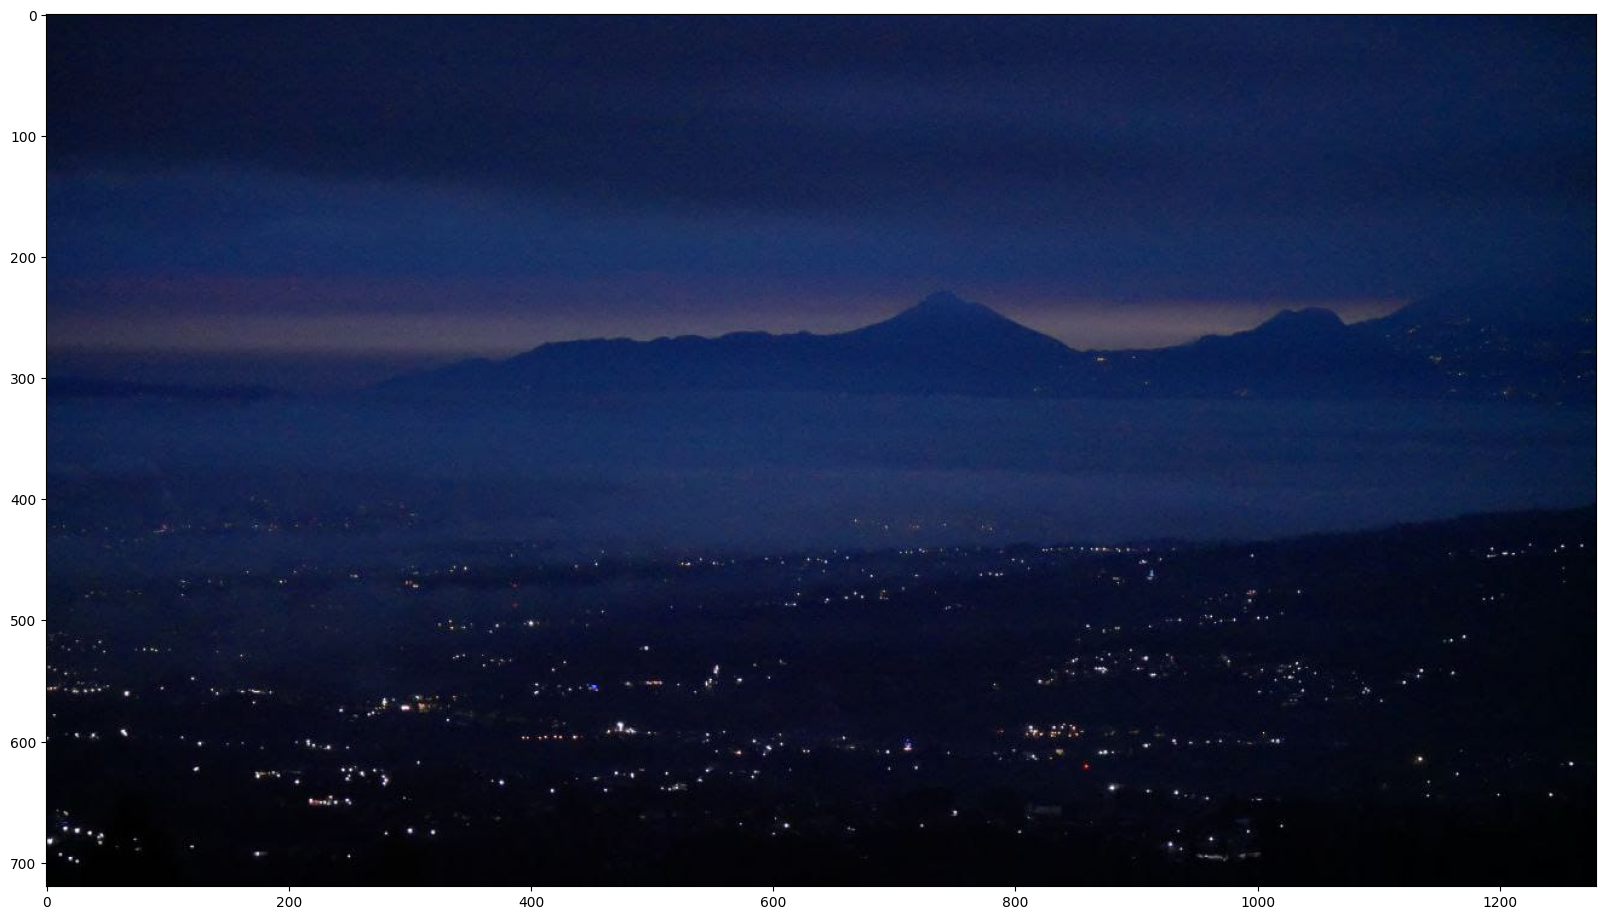

In [ ]:
import matplotlib.pyplot as plt
print("Shape sebelum figsize:", img.shape)

plt.figure(figsize=(20, 20))
plt.imshow(img_cv_rgb)

print("Shape setelah plot figsize (20,20):", img.shape)
